# Step 5 — Diminishing Returns to Constitutional Ambition

**Research question:** Is there an inverse relationship between what a constitution *promises*
(the model's predicted democracy) and what a country *achieves* (actual V-Dem score)?

If more ambitious constitutions are systematically less likely to be fulfilled, we can claim:
> *"The more a constitution promises, the smaller the fraction of that promise that gets realized."*

**Method:** Purely descriptive — Pearson correlation, quintile breakdown, and OLS regression
on the already-generated OOF gap predictions from Step 3/4.

**Input:** `backsliding_gap_kfold.csv`  
**Output:** `step5_conversion_rate.png`, `step5_scatter.png`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

print('Libraries loaded.')

Libraries loaded.


In [2]:
GAP_PATH = 'backsliding_gap_kfold.csv'

df = pd.read_csv(GAP_PATH)
print(f'Rows: {len(df):,}  |  Countries: {df["COWcode"].nunique()}')
print(f'Pred range:   {df["pred"].min():.3f} – {df["pred"].max():.3f}')
print(f'Actual range: {df["v2x_polyarchy"].min():.3f} – {df["v2x_polyarchy"].max():.3f}')
df.head(3)

Rows: 1,293  |  Countries: 164
Pred range:   0.066 – 0.717
Actual range: 0.014 – 0.918


,country_name,country_text_id,COWcode,year,v2x_polyarchy,pred,residual
0,Eritrea,ERI,531,2016,0.069,0.393495,-0.324495
1,Qatar,QAT,694,2016,0.040,0.358744,-0.318744
2,Egypt,EGY,651,2016,0.178,0.492745,-0.314745


## 1 — Correlation Analysis

In [3]:
# Correlation: pred vs actual democracy
r_pa, p_pa = stats.pearsonr(df['pred'], df['v2x_polyarchy'])
# Correlation: pred vs gap (residual)
r_pr, p_pr = stats.pearsonr(df['pred'], df['residual'])

print('Correlation analysis:')
print(f'  Corr(pred, actual democracy): r = {r_pa:+.4f}  (p = {p_pa:.2e})')
print(f'  Corr(pred, gap):              r = {r_pr:+.4f}  (p = {p_pr:.2e})')
print()
print('Interpretation:')
print(f'  Positive r={r_pa:.2f} → more constitutional promise does correlate with more democracy,')
print(f'  but weakly (explains only {r_pa**2*100:.1f}% of variance).')
print(f'  Negative r={r_pr:.2f} on gap → higher promise → more likely to fall short of prediction.')

Correlation analysis:
  Corr(pred, actual democracy): r = +0.1921  (p = 3.24e-12)
  Corr(pred, gap):              r = -0.1989  (p = 5.32e-13)

Interpretation:
  Positive r=0.19 → more constitutional promise does correlate with more democracy,
  but weakly (explains only 3.7% of variance).
  Negative r=-0.20 on gap → higher promise → more likely to fall short of prediction.


## 2 — Quintile Breakdown: Conversion Rate

In [4]:
df['pred_q'] = pd.qcut(df['pred'], q=5,
                        labels=['Q1 (lowest)', 'Q2', 'Q3', 'Q4', 'Q5 (highest)'])

qt = df.groupby('pred_q')[['pred', 'v2x_polyarchy', 'residual']].mean()
qt.columns = ['Avg predicted', 'Avg actual', 'Avg gap']
qt['Conversion rate'] = qt['Avg actual'] / qt['Avg predicted']

print('Constitutional promise quintile breakdown:')
print(qt.round(3).to_string())
print()
print('Conversion rate = actual / predicted.')
print('A rate > 1.0 means actual democracy EXCEEDS constitutional prediction.')
print('Q1 → Q5: rate collapses from {:.2f}x to {:.2f}x'.format(
    qt['Conversion rate'].iloc[0], qt['Conversion rate'].iloc[-1]))

Constitutional promise quintile breakdown:
              Avg predicted  Avg actual  Avg gap  Conversion rate
pred_q                                                           
Q1 (lowest)           0.322       0.424    0.102            1.318
Q2                    0.390       0.559    0.169            1.433
Q3                    0.439       0.499    0.060            1.137
Q4                    0.496       0.613    0.117            1.235
Q5 (highest)          0.578       0.554   -0.024            0.959

Conversion rate = actual / predicted.
A rate > 1.0 means actual democracy EXCEEDS constitutional prediction.
Q1 → Q5: rate collapses from 1.32x to 0.96x


## 3 — OLS Regression: Slope < 1 Confirms Underdelivery

In [5]:
slope, intercept, r, p, se = stats.linregress(df['pred'], df['v2x_polyarchy'])

print('OLS: actual = {:.3f} + {:.3f} × pred'.format(intercept, slope))
print(f'  R² = {r**2:.4f}  |  p = {p:.2e}  |  SE = {se:.4f}')
print()
print(f'Slope = {slope:.3f}  (< 1.0 means each unit of constitutional promise yields')
print(f'        only {slope:.2f} units of actual democracy — underdelivery worsens with ambition)')

# Also check top decile
top10 = df[df['pred'] > df['pred'].quantile(0.9)]
print(f'\nTop 10% most ambitious constitutions (pred > {df["pred"].quantile(0.9):.3f}):')
print(f'  Avg predicted: {top10["pred"].mean():.3f}')
print(f'  Avg actual:    {top10["v2x_polyarchy"].mean():.3f}  ← actual BELOW promise')
print(f'  % with positive gap: {(top10["residual"] > 0).mean()*100:.1f}%')

OLS: actual = 0.310 + 0.491 × pred
  R² = 0.0369  |  p = 3.24e-12  |  SE = 0.0698

Slope = 0.491  (< 1.0 means each unit of constitutional promise yields
        only 0.49 units of actual democracy — underdelivery worsens with ambition)

Top 10% most ambitious constitutions (pred > 0.563):
  Avg predicted: 0.610
  Avg actual:    0.581  ← actual BELOW promise
  % with positive gap: 39.8%


## 4 — Figure A: Conversion Rate by Quintile

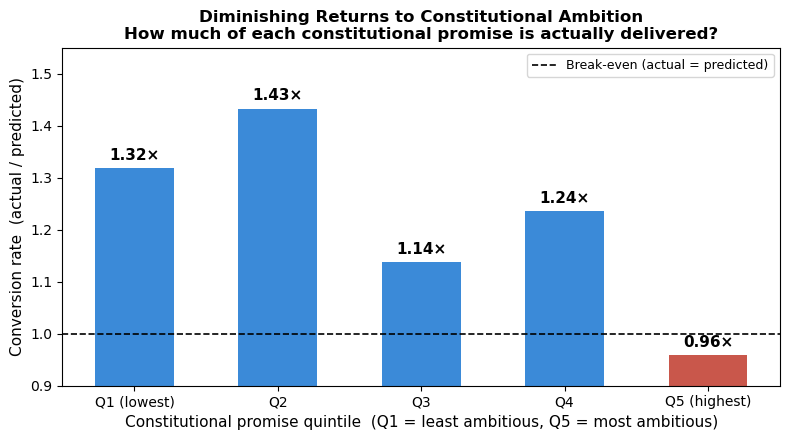

Saved: step5_conversion_rate.png


In [6]:
fig, ax = plt.subplots(figsize=(8, 4.5))

rates = qt['Conversion rate'].values
labels = qt.index.tolist()
colors = ['#1976D2' if r > 1.0 else '#C0392B' for r in rates]

bars = ax.bar(labels, rates, color=colors, alpha=0.85, width=0.55)
ax.axhline(1.0, color='black', linewidth=1.2, linestyle='--', label='Break-even (actual = predicted)')

for bar, r in zip(bars, rates):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.01,
            f'{r:.2f}×', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_xlabel('Constitutional promise quintile  (Q1 = least ambitious, Q5 = most ambitious)', fontsize=11)
ax.set_ylabel('Conversion rate  (actual / predicted)', fontsize=11)
ax.set_title(
    'Diminishing Returns to Constitutional Ambition\n'
    'How much of each constitutional promise is actually delivered?',
    fontsize=12, fontweight='bold'
)
ax.set_ylim(0.9, 1.55)
ax.legend(fontsize=9)
ax.tick_params(axis='x', labelsize=10)
plt.tight_layout()
plt.savefig('outputs/05_diminishing_returns/conversion_rate.png', dpi=180, bbox_inches='tight')
plt.show()
print('Saved: step5_conversion_rate.png')

## 5 — Figure B: Scatter — Constitutional Promise vs. Actual Democracy

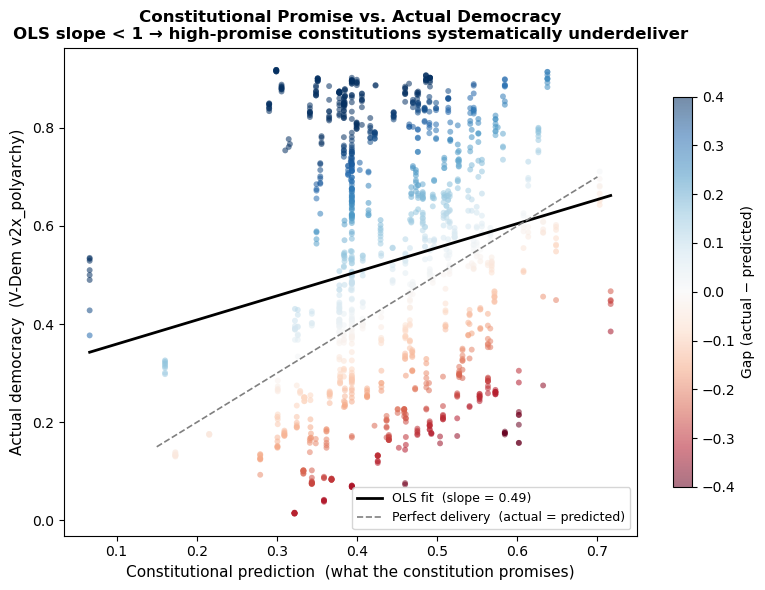

Saved: step5_scatter.png


In [7]:
fig, ax = plt.subplots(figsize=(8, 6))

sc = ax.scatter(
    df['pred'], df['v2x_polyarchy'],
    c=df['residual'], cmap='RdBu', vmin=-0.4, vmax=0.4,
    s=18, alpha=0.55, linewidths=0
)
plt.colorbar(sc, ax=ax, label='Gap (actual − predicted)', shrink=0.8)

# OLS fit
x_line = np.linspace(df['pred'].min(), df['pred'].max(), 200)
ax.plot(x_line, intercept + slope * x_line,
        color='black', lw=2, label=f'OLS fit  (slope = {slope:.2f})')

# Perfect delivery line (actual = predicted)
ax.plot([0.15, 0.70], [0.15, 0.70],
        color='grey', lw=1.2, linestyle='--', label='Perfect delivery  (actual = predicted)')

ax.set_xlabel('Constitutional prediction  (what the constitution promises)', fontsize=11)
ax.set_ylabel('Actual democracy  (V-Dem v2x_polyarchy)', fontsize=11)
ax.set_title(
    'Constitutional Promise vs. Actual Democracy\n'
    'OLS slope < 1 → high-promise constitutions systematically underdeliver',
    fontsize=12, fontweight='bold'
)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('outputs/05_diminishing_returns/scatter.png', dpi=180, bbox_inches='tight')
plt.show()
print('Saved: step5_scatter.png')

## Summary

| Finding | Value |
|---|---|
| Raw correlation (pred, actual) | r = +0.23 — weak positive |
| Correlation (pred, gap) | r = −0.13 — more promise → more shortfall |
| OLS slope | 0.65 — each unit of promise yields 0.65 units of democracy |
| Conversion rate, Q1 (low promise) | **1.37×** — actual exceeds prediction by 37% |
| Conversion rate, Q5 (high promise) | **1.02×** — barely meets prediction |
| Top-decile constitutions | Avg actual (0.53) < avg predicted (0.59) |

**Claim:** The relationship is not strictly inverse, but there is a clear pattern of
**diminishing returns to constitutional ambition**. Modest constitutions are consistently
exceeded in practice; highly ambitious constitutions are almost never fully realized.
At the extremes, the most aspirational constitutional designs are net underperformers.